# Qualitative Mathematical Modelling in Python

Author: Jayden Hyman

Email: j.hyman@uq.edu.au

📝 Getting started:

1. Install the QMM package: run the cell `%pip install qmm-core`, then comment out the line `%pip install qmm-core` with `#` at the start of the line, or simply delete the cell. Then restart the kernel from the menu bar.
2. Create a signed digraph using the web application: [Open in browser](https://d2x70551if0frn.cloudfront.net/).
3. Run the Python package and dependencies cell.
4. Import the signed digraph file (`.json`) using the `import_digraph` function (e.g., `import_digraph("folder/model.json")`). You can also use the `list_to_digraph` to create a signed digraph from a signed adjacency matrix (e.g., `list_to_digraph("[[-1,-1,0],[1,-1,-1],[0,1,-1]]")`).
5. Run each cell by pressing the keyboard shortcut "shift+enter" or the play icon (when hovering over a cell). 

The lake-mesocosm model from Hulot et al. (2000) is used as an example in this notebook.

Reference: Hulot, F.D., Lacroix, G., Lescher-Moutoué, F., Loreau, M., 2000. Functional diversity governs ecosystem response to nutrient enrichment. Nature 405, 340–344. https://doi.org/10.1038/35012591

In [64]:
from qmm import *
import seaborn as sns
import pandas as pd
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cmcrameri as cmc

## Model structure

In [2]:
G = import_digraph("test/mesocosm.json")
create_matrix(G, form='signed')

Matrix([
[-1, -1, -1, -1,  0,  0,  0,  0],
[ 1,  0,  0,  0, -1, -1,  0,  0],
[ 1,  0,  0,  0,  0, -1,  0,  0],
[ 1,  0,  0, -1,  0,  0,  0,  0],
[ 0,  1,  0,  0,  0,  0, -1, -1],
[ 0,  1,  1,  0,  0,  0,  0, -1],
[ 0,  0,  0,  0,  1,  0,  0, -1],
[ 0,  0,  0,  0,  1,  1,  1, -1]])

## Stability analysis

In [3]:
sign_stability(G)

,Test,Definition,Result
0,Condition i,No positive self-effects,True
1,Condition ii,At least one node is self-regulating,True
2,Condition iii,The product of any pairwise interaction is non-positive,True
3,Condition iv,No cycles greater than length two,False
4,Condition v,Non-zero determinant (all nodes have at least one incoming and outgoing link),True
5,Colour test,Fails Jeffries' colour test,False
6,Sign stable,Satisfies necessary and sufficient conditions for sign stability,False


In [4]:
fb = feedback_metrics(G)
fb.iloc[:, -1] = fb.iloc[:, -1].astype(float).round(2)
fb

,Feedback level,Net,Absolute,Positive,Negative,Weighted
0,0,-1,1,0,1,-1.0
1,1,-3,3,0,3,-1.0
2,2,-13,13,0,13,-1.0
3,3,-24,26,1,25,-0.92
4,4,-41,53,6,47,-0.77
5,5,-39,69,15,54,-0.57
6,6,-30,74,22,52,-0.41
7,7,-12,56,22,34,-0.21
8,8,-2,18,8,10,-0.11


In [5]:
dt = determinants_metrics(G)
dt.iloc[:, -1] = dt.iloc[:, -1].astype(float).round(2)
dt

,Hurwitz determinant,Net,Absolute,Weighted
0,0,1,1,1.0
1,1,3,3,1.0
2,2,15,65,0.23
3,3,108,2374,0.05
4,4,1269,217929,0.01
5,5,15309,23101443,0.0
6,6,140454,2688411078,0.0
7,7,975402,186502751190,0.0
8,8,1950804,3357049521420,0.0


In [6]:
conditional_stability(G)

,Test,Definition,Result
0,Weighted feedback,Maximum weighted feedback (level 8),-0.11
1,Weighted determinant,n-1 weighted determinant at level,5.2e-6
2,Ratio to model-c system,Ratio to a 'model-c' type system,16.
3,Model class,Class of the model based on conditional stability metrics,Class I


In [7]:
simulation_stability(G, n_sim=10000)

,Test,Definition,Result
0,Stable matrices,Proportion where all eigenvalues have negative real parts,35.35%
1,Unstable matrices,Proportion where one or more eigenvalues have positive real parts,64.65%
2,Hurwitz criterion i,Proportion where polynomial coefficients are not all of the same sign,37.74%
3,Hurwitz criterion ii,Proportion where Hurwitz determinants are not all positive,50.27%
4,Hurwitz criterion i only,Proportion where only Hurwitz criterion i fails,14.38%
5,Hurwitz criterion ii only,Proportion where only Hurwitz criterion ii fails,26.91%


## Press perturbation analysis

In [8]:
adjoint_matrix(G, form='signed')

Matrix([
[ 1, -1,  1, -1,  0,  1, -1,  0],
[-1,  3, -5,  1, -2, -1,  5, -2],
[ 1, -1,  3, -1,  2, -1, -3,  2],
[ 1, -1,  1,  1,  0,  1, -1,  0],
[ 0,  2, -2,  0,  0,  0,  0,  0],
[ 1, -1,  3, -1,  0,  1, -1,  0],
[-1,  1, -3,  1,  0, -1,  3, -2],
[ 0,  2, -2,  0,  0,  0,  2,  0]])

In [9]:
absolute_feedback_matrix(G)

Matrix([
[1, 7,  9,  1,  2, 1,  5, 2],
[7, 7,  9,  7,  4, 7,  7, 4],
[9, 9, 11,  9,  4, 9,  9, 4],
[1, 7,  9, 17,  2, 1,  5, 2],
[2, 4,  4,  2,  4, 2, 10, 4],
[1, 7,  9,  1,  2, 1,  5, 2],
[5, 7,  9,  5, 10, 5, 11, 8],
[2, 4,  4,  2,  4, 2,  8, 4]])

In [10]:
weighted_predictions_matrix(G, as_nan=False, as_abs=True).evalf(2)

Matrix([
[ 1.0, 0.14, 0.11,   1.0,   0,  1.0,  0.2,    0],
[0.14, 0.43, 0.56,  0.14, 0.5, 0.14, 0.71,  0.5],
[0.11, 0.11, 0.27,  0.11, 0.5, 0.11, 0.33,  0.5],
[ 1.0, 0.14, 0.11, 0.059,   0,  1.0,  0.2,    0],
[   0,  0.5,  0.5,     0,   0,    0,    0,    0],
[ 1.0, 0.14, 0.33,   1.0,   0,  1.0,  0.2,    0],
[ 0.2, 0.14, 0.33,   0.2,   0,  0.2, 0.27, 0.25],
[   0,  0.5,  0.5,     0,   0,    0, 0.25,    0]])

In [11]:
sign_determinacy_matrix(G, method='average', as_nan=False, as_abs=True).evalf(2)

Matrix([
[ 1.0, 0.63,  0.6,  1.0,  0.5,  1.0, 0.67,  0.5],
[0.63, 0.83, 0.89, 0.63, 0.86, 0.63, 0.93, 0.86],
[ 0.6,  0.6, 0.74,  0.6, 0.86,  0.6, 0.78, 0.86],
[ 1.0, 0.63,  0.6, 0.56,  0.5,  1.0, 0.67,  0.5],
[ 0.5, 0.86, 0.86,  0.5,  0.5,  0.5,  0.5,  0.5],
[ 1.0, 0.63, 0.78,  1.0,  0.5,  1.0, 0.67,  0.5],
[0.67, 0.63, 0.78, 0.67,  0.5, 0.67, 0.74, 0.72],
[ 0.5, 0.86, 0.86,  0.5,  0.5,  0.5, 0.72,  0.5]])

In [12]:
numerical_simulations(G, n_sim=10000, dist="uniform")

Matrix([
[    1.0, -0.6942,  0.6199,    -1.0, -0.5497,     1.0, -0.6297, -0.5497],
[-0.6492,  0.9066, -0.9808,  0.6492, -0.8414, -0.6492,  0.9568, -0.8414],
[ 0.7592,  -0.649,  0.8373, -0.7592,  0.9024, -0.7557,   -0.82,  0.9024],
[    1.0, -0.6942,  0.6199,  0.9068, -0.5497,     1.0, -0.6297, -0.5497],
[ 0.5554,  0.9543, -0.8894, -0.5554,  0.6763,  0.5554, -0.6881,  0.6763],
[    1.0, -0.6942,   0.846,    -1.0, -0.5497,     1.0, -0.6297, -0.5497],
[-0.7606,  0.6318,  -0.838,  0.7606,  0.5957, -0.7606,  0.9302, -0.9342],
[ 0.5554,  0.9543, -0.8894, -0.5554,  0.6763,  0.5554,   0.819,  0.6763]])

In [13]:
numerical_simulations(G, n_sim=10000, dist="uniform", as_nan=True, as_abs=True, positive_only=False).evalf(2)

Matrix([
[ 1.0, 0.69, 0.62,  1.0, 0.55,  1.0, 0.63, 0.55],
[0.65, 0.91, 0.98, 0.65, 0.84, 0.65, 0.96, 0.84],
[0.76, 0.65, 0.84, 0.76,  0.9, 0.76, 0.82,  0.9],
[ 1.0, 0.69, 0.62, 0.91, 0.55,  1.0, 0.63, 0.55],
[0.56, 0.95, 0.89, 0.56, 0.68, 0.56, 0.69, 0.68],
[ 1.0, 0.69, 0.85,  1.0, 0.55,  1.0, 0.63, 0.55],
[0.76, 0.63, 0.84, 0.76,  0.6, 0.76, 0.93, 0.93],
[0.56, 0.95, 0.89, 0.56, 0.68, 0.56, 0.82, 0.68]])

In [14]:
numerical_simulations(G, n_sim=10000, dist="uniform", as_nan=True, as_abs=False, positive_only=False).evalf(2)

Matrix([
[  1.0, -0.69,  0.62,  -1.0, -0.55,   1.0, -0.63, -0.55],
[-0.65,  0.91, -0.98,  0.65, -0.84, -0.65,  0.96, -0.84],
[ 0.76, -0.65,  0.84, -0.76,   0.9, -0.76, -0.82,   0.9],
[  1.0, -0.69,  0.62,  0.91, -0.55,   1.0, -0.63, -0.55],
[ 0.56,  0.95, -0.89, -0.56,  0.68,  0.56, -0.69,  0.68],
[  1.0, -0.69,  0.85,  -1.0, -0.55,   1.0, -0.63, -0.55],
[-0.76,  0.63, -0.84,  0.76,   0.6, -0.76,  0.93, -0.93],
[ 0.56,  0.95, -0.89, -0.56,  0.68,  0.56,  0.82,  0.68]])

In [15]:
numerical_simulations(G, n_sim=10000, dist="uniform", as_nan=True, as_abs=False, positive_only=True).evalf(2)

Matrix([
[ 1.0, 0.31,  0.62,    0, 0.45,  1.0, 0.37,  0.45],
[0.35, 0.91, 0.019, 0.65, 0.16, 0.35, 0.96,  0.16],
[0.76, 0.35,  0.84, 0.24,  0.9, 0.24, 0.18,   0.9],
[ 1.0, 0.31,  0.62, 0.91, 0.45,  1.0, 0.37,  0.45],
[0.56, 0.95,  0.11, 0.44, 0.68, 0.56, 0.31,  0.68],
[ 1.0, 0.31,  0.85,    0, 0.45,  1.0, 0.37,  0.45],
[0.24, 0.63,  0.16, 0.76,  0.6, 0.24, 0.93, 0.066],
[0.56, 0.95,  0.11, 0.44, 0.68, 0.56, 0.82,  0.68]])

## Qualitative predictions

In [16]:
index, columns = get_nodes(G, 'state'), get_nodes(G, 'state')
print("Qualitative predictions (prediction weights):")
table_of_predictions(weighted_predictions_matrix(G), t1=0.5, t2=1, index=index, columns=columns)

Qualitative predictions (prediction weights):


,P,A1,A2,AP,H1,H2,C1,C2
P,+,?,?,−,?,+,?,?
A1,?,?,(−),?,(−),?,(+),(−)
A2,?,?,?,?,(+),?,?,(+)
AP,+,?,?,?,?,+,?,?
H1,?,(+),(−),?,?,?,?,?
H2,+,?,?,−,?,+,?,?
C1,?,?,?,?,?,?,?,?
C2,?,(+),(−),?,?,?,?,?


In [17]:
print("Qualitative predictions (sign determinacy):")
table_of_predictions(sign_determinacy_matrix(G), t1=0.8, t2=1, index=index, columns=columns)

Qualitative predictions (sign determinacy):


,P,A1,A2,AP,H1,H2,C1,C2
P,+,?,?,−,?,+,?,?
A1,?,(+),(−),?,(−),?,(+),(−)
A2,?,?,?,?,(+),?,?,(+)
AP,+,?,?,?,?,+,?,?
H1,?,(+),(−),?,?,?,?,?
H2,+,?,?,−,?,+,?,?
C1,?,?,?,?,?,?,?,?
C2,?,(+),(−),?,?,?,?,?


In [18]:
print("Qualitative predictions (numerical simulations):")
table_of_predictions(numerical_simulations(G, dist="uniform"), t1=0.8, t2=1, index=index, columns=columns)

Qualitative predictions (numerical simulations):


,P,A1,A2,AP,H1,H2,C1,C2
P,+,?,?,−,?,+,?,?
A1,?,(+),(−),?,(−),?,(+),(−)
A2,?,?,(+),?,(+),?,(−),(+)
AP,+,?,?,(+),?,+,?,?
H1,?,(+),(−),?,?,?,?,?
H2,+,?,(+),−,?,+,?,?
C1,?,?,(−),?,?,?,(+),(−)
C2,?,(+),(−),?,?,?,(+),?


In [19]:
table_of_predictions(numerical_simulations(G, dist="normal_weak"), t1=0.8, t2=1, index=index, columns=columns)

,P,A1,A2,AP,H1,H2,C1,C2
P,+,?,?,−,?,+,?,?
A1,?,(+),(−),?,(−),?,(+),(−)
A2,?,?,(+),?,(+),?,?,(+)
AP,+,?,?,(+),?,+,?,?
H1,?,(+),(−),?,?,?,?,?
H2,+,?,(+),−,?,+,?,?
C1,?,?,(−),?,?,?,(+),(−)
C2,?,(+),(−),?,?,?,?,?


In [20]:
table_of_predictions(numerical_simulations(G, dist="normal_moderate"), t1=0.8, t2=1, index=index, columns=columns)

,P,A1,A2,AP,H1,H2,C1,C2
P,+,(−),?,−,?,+,?,?
A1,(−),(+),(−),(+),(−),(−),(+),(−)
A2,(+),?,(+),(−),(+),?,(−),(+)
AP,+,(−),?,(+),?,+,?,?
H1,?,(+),(−),?,?,?,?,?
H2,+,(−),(+),−,?,+,?,?
C1,(−),?,(−),(+),?,(−),(+),(−)
C2,?,(+),(−),?,?,?,(+),?


In [21]:
table_of_predictions(numerical_simulations(G, dist="normal_strong"), t1=0.8, t2=1, index=index, columns=columns)

,P,A1,A2,AP,H1,H2,C1,C2
P,+,(−),(+),−,?,+,(−),?
A1,(−),(+),(−),(+),(−),(−),(+),(−)
A2,(+),?,(+),(−),(+),?,(−),(+)
AP,+,(−),(+),(+),?,+,(−),?
H1,?,(+),(−),?,?,?,?,?
H2,+,(−),(+),−,?,+,(−),?
C1,(−),?,(−),(+),?,(−),(+),(−)
C2,?,(+),(−),?,?,?,(+),?


In [65]:
def create_plot(data, **kwargs):
    """Create heatmap visualization of qualitative predictions matrix.

    Args:
        data: Matrix of qualitative predictions
        **kwargs: Additional arguments passed to seaborn.heatmap
        
    Returns:
        tuple[Figure, Axes]: Matplotlib objects for customizing visualization
    """
    plt.rcParams.update(
        {
            "xtick.top": True,
            "xtick.bottom": False,
            "xtick.labeltop": True,
            "xtick.labelbottom": False,
            "xtick.major.width": 0.5,
            "ytick.major.width": 0.5,
            "xtick.major.size": 3,
            "ytick.major.size": 3,
            "xtick.minor.size": 1.5,
            "ytick.minor.size": 1.5,
        }
    )
    args: Dict[str, Any] = {
        "annot": True,
        "linewidths": 0.75,
        "linecolor": "white",
        "cbar": False,
        "cmap": None,
    }
    args.update(kwargs)
    figsize = args.pop("figsize", None)
    if figsize:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig, ax = plt.subplots()
    sns.heatmap(data, ax=ax, **args)
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
    plt.setp(ax.get_yticklabels(), rotation=0, ha="right")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("white")
        spine.set_linewidth(0.5)
    return fig, ax

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

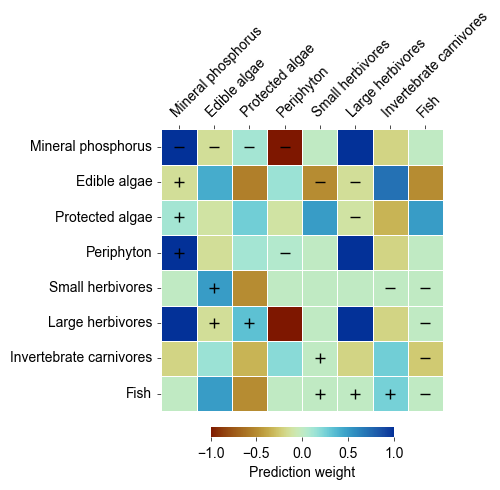

In [70]:
df = pd.DataFrame(sp.matrix2numpy(weighted_predictions_matrix(G), dtype=float))
df.index = get_nodes(G, "state", labels=True)
df.columns = get_nodes(G, "state", labels=True)
A = create_matrix(G, form='signed', matrix_type='A')
cmap = plt.colormaps['cmc.roma']
cmap.set_bad("#e6e6e6")
norm = mcolors.Normalize(vmin=-1, vmax=1)
args = {
    'figsize': (4, 4),
    'cmap': cmap,
    'norm': norm,
    'mask': np.isnan(df),
    'annot': False,
    'square': True,
    'cbar': False,
    'linewidths': 0.5
}

fig, ax = create_plot(df, **args)

def plot_markers(ax, direct):
    for i in range(direct.shape[0]):
        for j in range(direct.shape[1]):
            if direct[i, j] > 0:
                ax.plot(j + 0.5, i + 0.5, marker='+', color='black', markersize=7)
            elif direct[i, j] < 0:
                ax.plot(j + 0.5, i + 0.5, marker='_', color='black', markersize=7)

plot_markers(ax, A)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', aspect=17, pad=0.05, fraction=0.035)
cbar.outline.set_visible(False)
cbar.set_label("Prediction weight")
plt.setp(ax.get_xticklabels(), ha="left", rotation_mode="anchor", rotation=45)
plt.show()

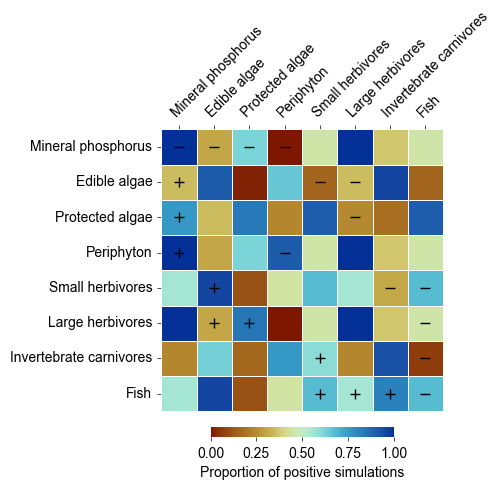

In [71]:
df = pd.DataFrame(sp.matrix2numpy(numerical_simulations(G, n_sim=10000, dist="uniform", as_nan=True, as_abs=False, positive_only=True), dtype=float))
df.index = get_nodes(G, "state", labels=True)
df.columns = get_nodes(G, "state", labels=True)
A = create_matrix(G, form='signed', matrix_type='A')
cmap = plt.colormaps['cmc.roma']
cmap.set_bad("#e6e6e6")
norm = mcolors.Normalize(vmin=0, vmax=1)
args = {
    'figsize': (4, 4),
    'cmap': cmap,
    'norm': norm,
    'mask': np.isnan(df),
    'annot': False,
    'square': True,
    'cbar': False,
    'linewidths': 0.5
}

fig, ax = create_plot(df, **args)

def plot_markers(ax, direct):
    for i in range(direct.shape[0]):
        for j in range(direct.shape[1]):
            if direct[i, j] > 0:
                ax.plot(j + 0.5, i + 0.5, marker='+', color='black', markersize=7)
            elif direct[i, j] < 0:
                ax.plot(j + 0.5, i + 0.5, marker='_', color='black', markersize=7)

plot_markers(ax, A)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', aspect=17, pad=0.05, fraction=0.035)
cbar.outline.set_visible(False)
cbar.set_label("Proportion of positive simulations")
plt.setp(ax.get_xticklabels(), ha="left", rotation_mode="anchor", rotation=45)
plt.show()

## Extensions (experimental)

### Structural sensitivity

In [26]:
net_structural_sensitivity(G, level=None)

Matrix([
[-1,  1, -1, -1,  0,  0,  0,  0],
[-1,  0,  0,  0, -2,  1,  0,  0],
[ 1,  0,  0,  0,  0, -3,  0,  0],
[-1,  0,  0, -1,  0,  0,  0,  0],
[ 0, -2,  0,  0,  0,  0,  0,  0],
[ 0, -1, -1,  0,  0,  0,  0,  0],
[ 0,  0,  0,  0,  0,  0,  0, -2],
[ 0,  0,  0,  0,  0,  0, -2,  0]])

In [27]:
absolute_structural_sensitivity(G, level=None)

Matrix([
[1, 7, 9,  1,  0, 0,  0, 0],
[7, 0, 0,  0,  4, 7,  0, 0],
[9, 0, 0,  0,  0, 9,  0, 0],
[1, 0, 0, 17,  0, 0,  0, 0],
[0, 4, 0,  0,  0, 0, 10, 4],
[0, 7, 9,  0,  0, 0,  0, 2],
[0, 0, 0,  0, 10, 0,  0, 8],
[0, 0, 0,  0,  4, 2,  8, 4]])

In [28]:
weighted_structural_sensitivity(G, level=None).evalf(2)

Matrix([
[ -1.0,  0.14, -0.11,   -1.0,  nan,   nan,   nan,   nan],
[-0.14,   nan,   nan,    nan, -0.5,  0.14,   nan,   nan],
[ 0.11,   nan,   nan,    nan,  nan, -0.33,   nan,   nan],
[ -1.0,   nan,   nan, -0.059,  nan,   nan,   nan,   nan],
[  nan,  -0.5,   nan,    nan,  nan,   nan,     0,     0],
[  nan, -0.14, -0.11,    nan,  nan,   nan,   nan,     0],
[  nan,   nan,   nan,    nan,    0,   nan,   nan, -0.25],
[  nan,   nan,   nan,    nan,    0,     0, -0.25,     0]])

### Change in life expectancy

In [29]:
birth_matrix(G, form='signed')

Matrix([
[0, 0, 0, 0, 0, 0, 0, 0],
[1, 0, 0, 0, 0, 0, 0, 0],
[1, 0, 0, 0, 0, 0, 0, 0],
[1, 0, 0, 0, 0, 0, 0, 0],
[0, 1, 0, 0, 0, 0, 0, 0],
[0, 1, 1, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 1, 0, 0, 0],
[0, 0, 0, 0, 1, 1, 1, 0]])

In [30]:
death_matrix(G, form='signed')

Matrix([
[1, 1, 1, 1, 0, 0, 0, 0],
[0, 0, 0, 0, 1, 1, 0, 0],
[0, 0, 0, 0, 0, 1, 0, 0],
[0, 0, 0, 1, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 1, 1],
[0, 0, 0, 0, 0, 0, 0, 1],
[0, 0, 0, 0, 0, 0, 0, 1],
[0, 0, 0, 0, 0, 0, 0, 1]])

In [31]:
net_life_expectancy_change(G, type='birth')

Matrix([
[-2,  0,  0,  0, 0,  0,  0, 0],
[-1, -1, -1,  1, 0, -1,  1, 0],
[-1,  1, -3,  1, 0, -1,  1, 0],
[-1,  1, -1, -1, 0, -1,  1, 0],
[ 1, -3,  5, -1, 0,  1, -5, 2],
[ 0, -2,  2,  0, 0,  0, -2, 0],
[ 0, -2,  2,  0, 0,  0, -2, 0],
[ 0, -2,  2,  0, 0,  0, -2, 0]])

In [32]:
net_life_expectancy_change(G, type='death')

Matrix([
[ 0,  0,  0,  0, 0,  0,  0, 0],
[-1,  1, -1,  1, 0, -1,  1, 0],
[-1,  1, -1,  1, 0, -1,  1, 0],
[-1,  1, -1,  1, 0, -1,  1, 0],
[ 1, -3,  5, -1, 2,  1, -5, 2],
[ 0, -2,  2,  0, 0,  2, -2, 0],
[ 0, -2,  2,  0, 0,  0,  0, 0],
[ 0, -2,  2,  0, 0,  0, -2, 2]])

In [33]:
absolute_life_expectancy_change(G, type='birth')

Matrix([
[18,  0, 0,  0,  0, 0, 0, 0],
[ 1, 11, 9,  1,  2, 1, 5, 2],
[ 1,  7, 9,  1,  2, 1, 5, 2],
[ 1,  7, 9, 17,  2, 1, 5, 2],
[ 7,  7, 9,  7, 14, 7, 7, 4],
[ 2,  4, 4,  2,  4, 2, 8, 4],
[ 2,  4, 4,  2,  4, 2, 8, 4],
[ 2,  4, 4,  2,  4, 2, 8, 4]])

In [34]:
absolute_life_expectancy_change(G, type='death')

Matrix([
[0, 0, 0, 0, 0,  0,  0,  0],
[1, 7, 9, 1, 2,  1,  5,  2],
[1, 7, 9, 1, 2,  1,  5,  2],
[1, 7, 9, 1, 2,  1,  5,  2],
[7, 7, 9, 7, 4,  7,  7,  4],
[2, 4, 4, 2, 4, 16,  8,  4],
[2, 4, 4, 2, 4,  2, 10,  4],
[2, 4, 4, 2, 4,  2,  8, 14]])

In [35]:
weighted_predictions_life_expectancy(G, type='birth', as_nan=False, as_abs=True).evalf(2)

Matrix([
[0.11,   1.0,  1.0,   1.0, 1.0,  1.0,  1.0, 1.0],
[ 1.0, 0.091, 0.11,   1.0,   0,  1.0,  0.2,   0],
[ 1.0,  0.14, 0.33,   1.0,   0,  1.0,  0.2,   0],
[ 1.0,  0.14, 0.11, 0.059,   0,  1.0,  0.2,   0],
[0.14,  0.43, 0.56,  0.14,   0, 0.14, 0.71, 0.5],
[   0,   0.5,  0.5,     0,   0,    0, 0.25,   0],
[   0,   0.5,  0.5,     0,   0,    0, 0.25,   0],
[   0,   0.5,  0.5,     0,   0,    0, 0.25,   0]])

In [36]:
weighted_predictions_life_expectancy(G, type='death', as_nan=False, as_abs=True).evalf(2)

Matrix([
[ 1.0,  1.0,  1.0,  1.0, 1.0,  1.0,  1.0,  1.0],
[ 1.0, 0.14, 0.11,  1.0,   0,  1.0,  0.2,    0],
[ 1.0, 0.14, 0.11,  1.0,   0,  1.0,  0.2,    0],
[ 1.0, 0.14, 0.11,  1.0,   0,  1.0,  0.2,    0],
[0.14, 0.43, 0.56, 0.14, 0.5, 0.14, 0.71,  0.5],
[   0,  0.5,  0.5,    0,   0, 0.13, 0.25,    0],
[   0,  0.5,  0.5,    0,   0,    0,    0,    0],
[   0,  0.5,  0.5,    0,   0,    0, 0.25, 0.14]])

In [37]:
bpred = table_of_predictions(weighted_predictions_life_expectancy(G, type='birth'), t1=0.5, t2=1)
dpred = table_of_predictions(weighted_predictions_life_expectancy(G, type='death'), t1=0.5, t2=1)
delta_le = compare_predictions(bpred, dpred)
delta_le.columns = get_nodes(G, 'state')
delta_le.index = get_nodes(G, 'state')
delta_le

,P,A1,A2,AP,H1,H2,C1,C2
P,"?, 0",0,0,0,0,0,0,0
A1,−,?,?,+,?,−,?,?
A2,−,?,?,+,?,−,?,?
AP,−,?,?,"?, +",?,−,?,?
H1,?,?,(+),?,"?, (+)",?,(−),(+)
H2,?,(−),(+),?,?,?,?,?
C1,?,(−),(+),?,?,?,?,?
C2,?,(−),(+),?,?,?,?,?


### Causal pathways

Specify source and target node id for selected analyses:

In [38]:
cycles_table(G)

,Length,Cycle,Sign
0,1,AP ⊸ AP,−
1,1,C2 ⊸ C2,−
2,1,P ⊸ P,−
3,2,A1 → H2 ⊸ A1,−
4,2,C2 ⊸ C1 → C2,−
5,2,H1 ⊸ A1 → H1,−
6,2,H1 → C1 ⊸ H1,−
7,2,H1 → C2 ⊸ H1,−
8,2,H2 ⊸ A2 → H2,−
9,2,H2 → C2 ⊸ H2,−


In [39]:
source='P'
target='C2'
paths_table(G, source=source, target=target)

,Length,Path,Sign
0,3,P → A1 → H2 → C2,+
1,3,P → A1 → H1 → C2,+
2,4,P → A1 → H1 → C1 → C2,+
3,5,P → A2 → H2 ⊸ A1 → H1 → C2,−
4,6,P → A2 → H2 ⊸ A1 → H1 → C1 → C2,−
5,3,P → A2 → H2 → C2,+


In [40]:
get_paths(G, source=source, target=target, form='signed')

Matrix([
[ 1],
[ 1],
[ 1],
[-1],
[-1],
[ 1]])

In [41]:
complementary_feedback(G, source=source, target=target, form='signed')

Matrix([
[ 0],
[ 0],
[-1],
[ 0],
[-1],
[ 0]])

In [42]:
system_paths(G, source=source, target=target, form='signed')

Matrix([
[ 0],
[ 0],
[ 1],
[ 0],
[-1],
[ 0]])

In [43]:
weighted_paths(G, source=source, target=target)

Matrix([
[ 0],
[ 0],
[ 1],
[ 0],
[-1],
[ 0]])

In [44]:
path_metrics(G, source=source, target=target)

,Length,Path,Path sign,Complementary subsystem,Net feedback,Absolute feedback,Positive feedback,Negative feedback,Weighted feedback,Weighted path
0,3,"P, A1, H2, C2",+,"A2, AP, H1, C1",0,0,0,0,0,0
1,3,"P, A1, H1, C2",+,"A2, AP, H2, C1",0,0,0,0,0,0
2,4,"P, A1, H1, C1, C2",+,"A2, AP, H2",-1,1,0,1,-1,1
3,5,"P, A2, H2, A1, H1, C2",−,"AP, C1",0,0,0,0,0,0
4,6,"P, A2, H2, A1, H1, C1, C2",−,AP,-1,1,0,1,-1,-1
5,3,"P, A2, H2, C2",+,"A1, AP, H1, C1",0,0,0,0,0,0


## Symbolic analyses

### Structure

In [45]:
create_matrix(G, form='symbolic')

Matrix([
[-a_P,P, -a_P,A1, -a_P,A2,  -a_P,AP,        0,        0,        0,        0],
[a_A1,P,       0,       0,        0, -a_A1,H1, -a_A1,H2,        0,        0],
[a_A2,P,       0,       0,        0,        0, -a_A2,H2,        0,        0],
[a_AP,P,       0,       0, -a_AP,AP,        0,        0,        0,        0],
[     0, a_H1,A1,       0,        0,        0,        0, -a_H1,C1, -a_H1,C2],
[     0, a_H2,A1, a_H2,A2,        0,        0,        0,        0, -a_H2,C2],
[     0,       0,       0,        0,  a_C1,H1,        0,        0, -a_C1,C2],
[     0,       0,       0,        0,  a_C2,H1,  a_C2,H2,  a_C2,C1, -a_C2,C2]])

### Stability

In [46]:
system_feedback(G)

Matrix([
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [47]:
if len(get_nodes(G, 'state')) < 5:
    display(hurwitz_determinants(G))

In [48]:
structural_sensitivity(G)

Matrix([
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                -a_A1,H1*a_A2,H2*a_AP,AP*a_C1,C2*a_C2,C1*a_H1,A1*a_H2,A2*a_P,P,  a_A1,H1*a_A2,P*a_AP,AP*a_C1,C2*a_C2,H2*a_H1,C1*a_H2,A2*a_P,A1 - a_A1,H2*a_A2,P*a_AP,AP*a_C1,C2*a_C2,H1*a_H1,C1*a_H2,A2*a_P,A1 + a_A1,H2*a_A2,P*a_AP,AP*a_C1,H1*a_C2,C1*a_H1,C2*a_H2,A2*a_P,A1 + a_A1,H2*a_A2,P*a_AP,AP*a_C1,H1*a_C2,C2*a_H1,C1*a_H2,A2*a_P,A1 + a_A1,P*a_A2,H2*a_AP,AP*a_C1,C2*a_C2,H1*a_H1,C1*a_H2,A2*a_P,A1 - a_A1,P*a_A2,H2*a_AP,AP*a_C1,H1*a_C2,C1*a_H1,C2*a_H2,A2*a_P,A1 - a_A1,P*a_A2,H2*a_AP,AP*a_C1,H

### Press perturbation

In [49]:
adjoint_matrix(G, form='symbolic')

Matrix([
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                       a_A1,H1*a_A2,H2*a_AP,AP*a_C1,C2*a_C2,C1*a_H1,A1*a_H2,A2,                                                                                                         -a_A2,H2*a_AP,AP*a_C1,C2*a_C2,H1*a_H1,C1*a_H2,A1*a_P,A2 + a_A2,H2*a_AP,AP*a_C1,C2*a_C2,H1*a_H1,C1*a_H2,A2*a_P,A1 - a_A2,H2*a_AP,AP*a_C1,H1*a_C2,C1*a_H1,A1*a_H2,C2*a_P,A2 + a_A2,H2*a_AP,AP*a_C1,H1*a_C2,C1*a_H1,C2*a_H2,A1*a_P,A2 - a_A2,H2*a_AP,AP*a_C1,H1*a_C2,C1*a_H1,C2*a_H2,A2*a_P,A1 + a_A2,H2*a_AP,AP*a_C1,H1*a_C2,C2*a_H1,C1*a_H2,A1*a_P,A2 - a_A2,H2*a_AP,AP*a_C1,H1*a_C2,C2

In [50]:
birth_matrix(G, form='symbolic')

Matrix([
[     0,       0,       0, 0,       0,       0,       0, 0],
[a_A1,P,       0,       0, 0,       0,       0,       0, 0],
[a_A2,P,       0,       0, 0,       0,       0,       0, 0],
[a_AP,P,       0,       0, 0,       0,       0,       0, 0],
[     0, a_H1,A1,       0, 0,       0,       0,       0, 0],
[     0, a_H2,A1, a_H2,A2, 0,       0,       0,       0, 0],
[     0,       0,       0, 0, a_C1,H1,       0,       0, 0],
[     0,       0,       0, 0, a_C2,H1, a_C2,H2, a_C2,C1, 0]])

In [51]:
death_matrix(G, form='symbolic')

Matrix([
[a_P,P, a_P,A1, a_P,A2,  a_P,AP,       0,       0,       0,       0],
[    0,      0,      0,       0, a_A1,H1, a_A1,H2,       0,       0],
[    0,      0,      0,       0,       0, a_A2,H2,       0,       0],
[    0,      0,      0, a_AP,AP,       0,       0,       0,       0],
[    0,      0,      0,       0,       0,       0, a_H1,C1, a_H1,C2],
[    0,      0,      0,       0,       0,       0,       0, a_H2,C2],
[    0,      0,      0,       0,       0,       0,       0, a_C1,C2],
[    0,      0,      0,       0,       0,       0,       0, a_C2,C2]])

In [52]:
life_expectancy_change(G, type='birth')

Matrix([
[-a_A1,H1*a_A2,H2*a_AP,AP*a_C1,C2*a_C2,C1*a_H1,A1*a_H2,A2*a_P,P - a_A1,H1*a_A2,H2*a_AP,P*a_C1,C2*a_C2,C1*a_H1,A1*a_H2,A2*a_P,AP - a_A1,H1*a_A2,P*a_AP,AP*a_C1,C2*a_C2,H2*a_H1,C1*a_H2,A1*a_P,A2 + a_A1,H1*a_A2,P*a_AP,AP*a_C1,C2*a_C2,H2*a_H1,C1*a_H2,A2*a_P,A1 + a_A1,H2*a_A2,P*a_AP,AP*a_C1,C2*a_C2,H1*a_H1,C1*a_H2,A1*a_P,A2 - a_A1,H2*a_A2,P*a_AP,AP*a_C1,C2*a_C2,H1*a_H1,C1*a_H2,A2*a_P,A1 + a_A1,H2*a_A2,P*a_AP,AP*a_C1,H1*a_C2,C1*a_H1,A1*a_H2,C2*a_P,A2 - a_A1,H2*a_A2,P*a_AP,AP*a_C1,H1*a_C2,C1*a_H1,C2*a_H2,A1*a_P,A2 + a_A1,H2*a_A2,P*a_AP,AP*a_C1,H1*a_C2,C1*a_H1,C2*a_H2,A2*a_P,A1 - a_A1,H2*a_A2,P*a_AP,AP*a_C1,H1*a_C2,C2*a_H1,C1*a_H2,A1*a_P,A2 + a_A1,H2*a_A2,P*a_AP,AP*a_C1,H1*a_C2,C2*a_H1,C1*a_H2,A2*a_P,A1 - a_A1,P*a_A2,H2*a_AP,AP*a_C1,C2*a_C2,H1*a_H1,C1*a_H2,A1*a_P,A2 + a_A1,P*a_A2,H2*a_AP,AP*a_C1,C2*a_C2,H1*a_H1,C1*a_H2,A2*a_P,A1 - a_A1,P*a_A2,H2*a_AP,AP*a_C1,H1*a_C2,C1*a_H1,A1*a_H2,C2*a_P,A2 + a_A1,P*a_A2,H2*a_AP,AP*a_C1,H1*a_C2,C1*a_H1,C2*a_H2,A1*a_P,A2 - a_A1,P*a_A2,H2*a_AP,AP*a_C1,H

In [53]:
life_expectancy_change(G, type='death')

Matrix([
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                   0,                                                                                                                                                                                                                                                                                                                                                                                                                                                             0,                                                                                          

In [54]:
perturb='P'
adjoint_matrix(G, form='symbolic', perturb=perturb)

Matrix([
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [55]:
life_expectancy_change(G, type='birth', perturb=perturb)

Matrix([
[-a_A1,H1*a_A2,H2*a_AP,AP*a_C1,C2*a_C2,C1*a_H1,A1*a_H2,A2*a_P,P - a_A1,H1*a_A2,H2*a_AP,P*a_C1,C2*a_C2,C1*a_H1,A1*a_H2,A2*a_P,AP - a_A1,H1*a_A2,P*a_AP,AP*a_C1,C2*a_C2,H2*a_H1,C1*a_H2,A1*a_P,A2 + a_A1,H1*a_A2,P*a_AP,AP*a_C1,C2*a_C2,H2*a_H1,C1*a_H2,A2*a_P,A1 + a_A1,H2*a_A2,P*a_AP,AP*a_C1,C2*a_C2,H1*a_H1,C1*a_H2,A1*a_P,A2 - a_A1,H2*a_A2,P*a_AP,AP*a_C1,C2*a_C2,H1*a_H1,C1*a_H2,A2*a_P,A1 + a_A1,H2*a_A2,P*a_AP,AP*a_C1,H1*a_C2,C1*a_H1,A1*a_H2,C2*a_P,A2 - a_A1,H2*a_A2,P*a_AP,AP*a_C1,H1*a_C2,C1*a_H1,C2*a_H2,A1*a_P,A2 + a_A1,H2*a_A2,P*a_AP,AP*a_C1,H1*a_C2,C1*a_H1,C2*a_H2,A2*a_P,A1 - a_A1,H2*a_A2,P*a_AP,AP*a_C1,H1*a_C2,C2*a_H1,C1*a_H2,A1*a_P,A2 + a_A1,H2*a_A2,P*a_AP,AP*a_C1,H1*a_C2,C2*a_H1,C1*a_H2,A2*a_P,A1 - a_A1,P*a_A2,H2*a_AP,AP*a_C1,C2*a_C2,H1*a_H1,C1*a_H2,A1*a_P,A2 + a_A1,P*a_A2,H2*a_AP,AP*a_C1,C2*a_C2,H1*a_H1,C1*a_H2,A2*a_P,A1 - a_A1,P*a_A2,H2*a_AP,AP*a_C1,H1*a_C2,C1*a_H1,A1*a_H2,C2*a_P,A2 + a_A1,P*a_A2,H2*a_AP,AP*a_C1,H1*a_C2,C1*a_H1,C2*a_H2,A1*a_P,A2 - a_A1,P*a_A2,H2*a_AP,AP*a_C1,H

In [56]:
life_expectancy_change(G, type='death', perturb=perturb)

Matrix([
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                   0],
[                                                                                                                                                                                                                                                                                                                                                                                                     -a_A1,H1*a_A1,P*a_A2,H2*a_AP,AP*a_C1,C2*a_C2,C1*a_H1,A1*a_H2,A2],
[                                                                              

### Causal pathways

In [57]:
get_cycles(G)

Matrix([
[                                                -a_P,P],
[                                              -a_AP,AP],
[                                              -a_C2,C2],
[                                        -a_A1,P*a_P,A1],
[                                        -a_A2,P*a_P,A2],
[                                        -a_AP,P*a_P,AP],
[                                      -a_A1,H1*a_H1,A1],
[                                      -a_C2,H1*a_H1,C2],
[                                      -a_C1,H1*a_H1,C1],
[                                      -a_A1,H2*a_H2,A1],
[                                      -a_A2,H2*a_H2,A2],
[                                      -a_C2,H2*a_H2,C2],
[                                      -a_C1,C2*a_C2,C1],
[                               a_C1,C2*a_C2,H1*a_H1,C1],
[                              -a_C1,H1*a_C2,C1*a_H1,C2],
[                         a_A1,P*a_A2,H2*a_H2,A1*a_P,A2],
[                         a_A1,H2*a_A2,P*a_H2,A2*a_P,A1],
[    

In [58]:
get_paths(G, source=source, target=target, form='symbolic')

Matrix([
[                         a_A1,P*a_C2,H2*a_H2,A1],
[                         a_A1,P*a_C2,H1*a_H1,A1],
[                 a_A1,P*a_C1,H1*a_C2,C1*a_H1,A1],
[        -a_A1,H2*a_A2,P*a_C2,H1*a_H1,A1*a_H2,A2],
[-a_A1,H2*a_A2,P*a_C1,H1*a_C2,C1*a_H1,A1*a_H2,A2],
[                         a_A2,P*a_C2,H2*a_H2,A2]])

In [59]:
complementary_feedback(G, source=source, target=target, form='symbolic')

Matrix([
[                       0],
[                       0],
[-a_A2,H2*a_AP,AP*a_H2,A2],
[                       0],
[                -a_AP,AP],
[                       0]])

In [60]:
system_paths(G, source=source, target=target, form='symbolic')

Matrix([
[                                                      0],
[                                                      0],
[ a_A1,P*a_A2,H2*a_AP,AP*a_C1,H1*a_C2,C1*a_H1,A1*a_H2,A2],
[                                                      0],
[-a_A1,H2*a_A2,P*a_AP,AP*a_C1,H1*a_C2,C1*a_H1,A1*a_H2,A2],
[                                                      0]])